#import libraries and data

In [115]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("train_with_lags_2.csv")   # your cleaned dataset
df = df.sort_values("date_id")         # important for time-series modeling

# split up training and validation sets

In [116]:
TARGET = "forward_returns"

feature_cols = [c for c in df.columns
                if c not in ["date_id", TARGET, "risk_free_rate", "market_forward_excess_returns"]]

# LGBM traning

In [117]:
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df[TARGET]

# Splitting the data into training and validation sets. Adjust test_size as needed.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False) # shuffle=False is important for time-series data

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (7216, 114)
y_train shape: (7216,)
X_val shape: (1805, 114)
y_val shape: (1805,)


In [118]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_val,   label=y_val)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.03,
    "num_leaves": 50,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 4,
    "verbose": -1
}

model = lgb.train(
    params,
    train_set=train_data,
    valid_sets=[train_data, val_data],
    num_boost_round=3000,
    callbacks=[lgb.early_stopping(200)]
)

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[10]	training's rmse: 0.0101478	valid_1's rmse: 0.0110847


# feature importance

In [119]:
from sklearn.metrics import mean_squared_error
import numpy as np # Import numpy for sqrt function

preds_val = model.predict(X_val)
mse = mean_squared_error(y_val, preds_val) # Calculate MSE
rmse = np.sqrt(mse) # Take the square root to get RMSE
print("Validation RMSE:", rmse)

Validation RMSE: 0.011084685534898556


# save model

In [120]:
model.save_model("lightgbm_forward_returns.txt")

#accuracy check

In [121]:

# Load ground-truth data
df = pd.read_csv("test_with_lags.csv")

# Load predictions
preds = pd.read_csv("lightgbm_forward_returns.txt", header=None, names=["prediction"])

df["prediction"] = preds["prediction"]

#accuracy metrics & directional accuracy

In [122]:
true = y_val
pred = preds_val

mae = np.mean(np.abs(true - pred))
rmse = np.sqrt(np.mean((true - pred) ** 2))
corr = np.corrcoef(true, pred)[0,1]
r2   = r2_score(true, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("Correlation:", corr)
print("r^2:", r2)

# MAE 0.009 means model predictions are off by 9% daily on average
# RMSE 0.12 is low enough, and close enough to MAE
# correlation of 0.13 supposedly unusually strong according to chatGPT
# r^2 0.16 still good in practice, but on lower end

MAE: 0.00791435967310011
RMSE: 0.011084685534898556
Correlation: 0.04758502827694519
r^2: 0.0018667992410815737


In [123]:
direction_accuracy = (np.sign(true) == np.sign(pred)).mean()
print("Directional Accuracy:", direction_accuracy)

# directional accuracy of 0.54 supposedly very good according to chatGPT

Directional Accuracy: 0.5346260387811634


# plot for visual assistance

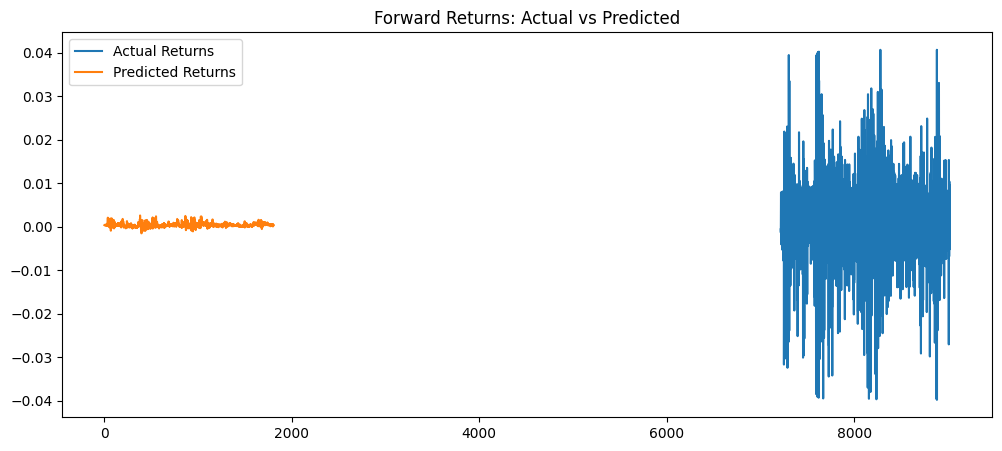

In [124]:
plt.figure(figsize=(12,5))
plt.plot(true, label="Actual Returns")
plt.plot(pred, label="Predicted Returns")
plt.legend()
plt.title("Forward Returns: Actual vs Predicted")
plt.show()

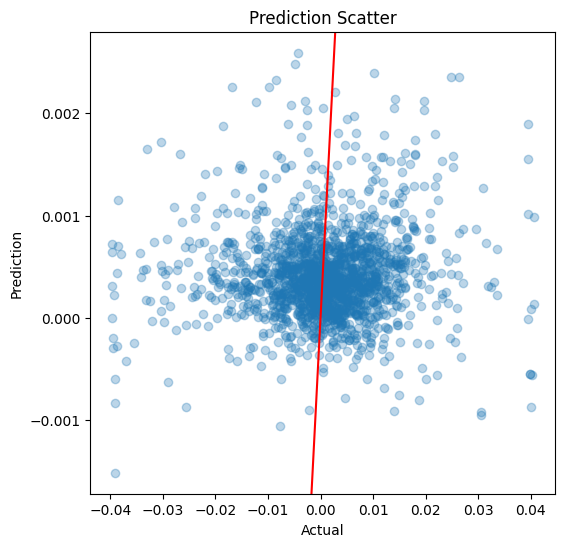

In [125]:
plt.figure(figsize=(6,6))
plt.scatter(true, pred, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Prediction")
plt.title("Prediction Scatter")
plt.axline((0, 0), slope=1, color="red")
plt.show()

# sharpe ratio

In [126]:
pred_dir = np.sign(pred)
strategy_return = pred_dir * true

sharpe = (strategy_return.mean() / strategy_return.std()) * np.sqrt(252)
print("Strategy Sharpe Ratio:", sharpe)

#

Strategy Sharpe Ratio: 0.60370650585992


#cumulative returns

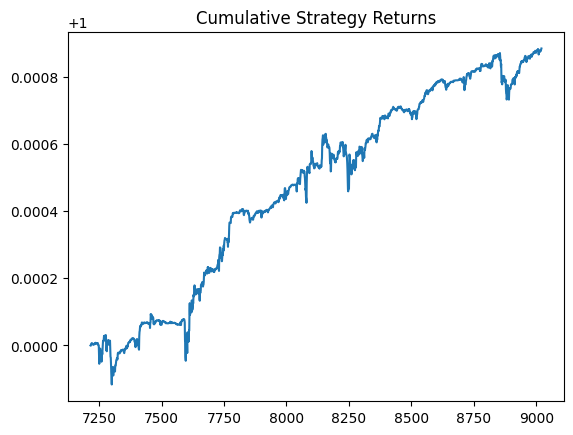

In [127]:
strategy_returns = preds_val * y_val
cum_returns = (1 + strategy_returns).cumprod()

plt.plot(cum_returns)
plt.title("Cumulative Strategy Returns")
plt.show()

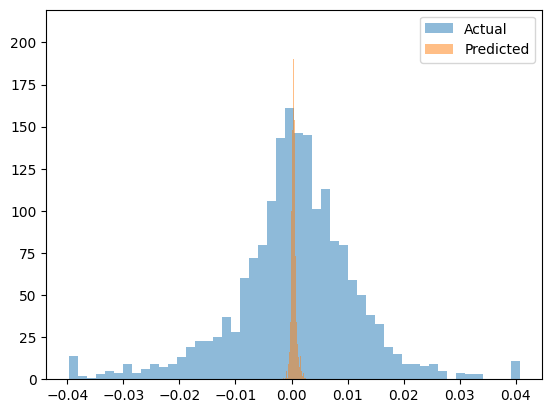

In [128]:
plt.hist(y_val, bins=50, alpha=0.5, label='Actual')
plt.hist(preds_val, bins=50, alpha=0.5, label='Predicted')
plt.legend()
plt.show()

# Task
Improve the LightGBM time-series forecasting model by tuning hyperparameters, enhancing feature engineering, implementing time-series cross-validation, analyzing feature importance, and summarizing the findings and recommendations. Use the "train_with_lags_2.csv" dataset for this task.

## Tune LightGBM Parameters

### Subtask:
Implement hyperparameter tuning for the LightGBM model using techniques like GridSearchCV or RandomizedSearchCV to find an optimal set of parameters (e.g., 'num_leaves', 'learning_rate', 'feature_fraction', 'bagging_fraction') that could lead to improved correlation and prediction accuracy. This step will involve defining a parameter grid and fitting the model with different parameter combinations.


**Reasoning**:
The first step is to import the necessary libraries, define the parameter grid for hyperparameter tuning, instantiate the LGBMRegressor model, and then set up and fit the GridSearchCV object to find the best parameters. It is important to use `TimeSeriesSplit` for cross-validation given the time-series nature of the data.



In [ ]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Define a parameter grid for LightGBM
param_grid = {
    'num_leaves': [31, 50, 70],
    'learning_rate': [0.01, 0.03, 0.05],
    'feature_fraction': [0.7, 0.8, 0.9],
    'bagging_fraction': [0.7, 0.8, 0.9],
    'bagging_freq': [1, 4],
    'n_estimators': [500, 1000, 1500] # Added n_estimators for LGBMRegressor
}

# Instantiate an LGBMRegressor model object
# Using some of the parameters from the previous model as base
lgbm = LGBMRegressor(
    objective='regression',
    metric='rmse',
    min_child_samples=50, # equivalent to min_data_in_leaf
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=-1 # Suppress verbose output during training
)

# Instantiate TimeSeriesSplit for time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Instantiate GridSearchCV
# Using 'neg_root_mean_squared_error' as scoring metric to find the best RMSE
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=2, # Set verbose to 2 to see the progress of the search
    n_jobs=-1 # Use all available cores
)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found by GridSearchCV
print("Best parameters found by GridSearchCV:", grid_search.best_params_)

# Print the best score (RMSE) achieved by the best parameters
# Note: neg_root_mean_squared_error is negative, so we negate it to get actual RMSE
print("Best RMSE found by GridSearchCV:", -grid_search.best_score_)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
